# Skeleton-of-Thought

1. **Skeleton Stage**：拆解問題的主要框架或骨架。
2. **Point-expanding Stage**：進一步擴展每個骨架的具體細節。
將前一日的新聞資料依據 Skeleton Stage 拆解的每個判斷依據都做一次判斷隔日漲跌  
e.g. 20230104的新聞判斷漲跌後存在20230105  
儲存格式：  
20230105  
判斷依據1: 由20230104的新聞判斷為漲  
判斷依據2: 由20230104的新聞判斷為跌  
...  


檔案說明：  
存在 out_twii/sot  


In [16]:
import os
import json
import textwrap
import pandas as pd
import numpy as np
from collections import Counter
from datetime import datetime
from dateutil.relativedelta import relativedelta
from IPython.display import display
from IPython.display import Markdown

from langchain_openai import ChatOpenAI


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatOpenAI(
  openai_api_key = os.getenv('OPENAI_API_KEY'),
  model='gpt-4o-mini',
  temperature=1,
)

# 買進賣出需要的手續費
fee = {
  'tax_stock' : 0.003,
  'tax_future' : 0.00002 * 2, # 買進與賣出各0.00002
  'fee_stock' : 0.001425 * 2, # 買進與賣出各0.001425
  'fee_future' : 0.00002 * 2, # 個家不大相同，以交易稅計算
  'sliding_price' : 0.00001, # 0.03%
}

# print(llm.invoke("hello world"))
# print(llm.model_name)
# print(llm.model_kwargs)

# path_price = os.path.join(os.path.abspath(os.path.dirname(os.getcwd())), 'history_data', 'tw', 'stock_price', id + 'tech.csv')
# path_news_title = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + id + "news_title.json"
symbol = "AAPL"
path_price = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/us/dataset/stocknet/price/raw/" + symbol
path_news = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/us/dataset/stocknet/tweet/preprocessed/" + symbol
path_out = "out_GA_sot/stocknet/" + symbol

In [17]:
# 寫一個從第2014年開始的函數
def get_date_range(start_date, end_date):
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    date_list = []
    while start_date <= end_date:
        date_list.append(start_date.strftime("%Y-%m-%d"))
        start_date += relativedelta(days=1)
    return date_list

date_list = get_date_range("2014-01-01", "2015-12-31")
# print(date_list)

In [13]:
# # 讀取新聞
# for day in date_list:
#     if os.path.exists(path_news + "/" + day) == False:
#         continue
#     with open(path_news + "/" + day, 'r') as f:
#         news = f.read()
#         print(news)

# 讀取股價
price = pd.read_csv(path_price + ".csv")

# 抓特定時間範圍的股價
price = price[price['Date'].isin(date_list)]
print(price)
# 計算股價變化
# 計算當日開盤到收盤的股價變化
price["Movement_Percent"] = (price["Close"] - price["Open"]) / price["Open"]
price["Movement"] = np.where(price["Movement_Percent"] > 0, 1, 0)
print(price)
actual_date_list = price["Date"].tolist()
print(actual_date_list)

           Date        Open        High         Low       Close   Adj Close  \
333  2014-01-02   79.382858   79.575714   78.860001   79.018570   73.522530   
334  2014-01-03   78.980003   79.099998   77.204285   77.282860   71.907555   
335  2014-01-06   76.778572   78.114288   76.228569   77.704285   72.299644   
336  2014-01-07   77.760002   77.994286   76.845711   77.148575   71.782608   
337  2014-01-08   76.972855   77.937141   76.955711   77.637146   72.237190   
..          ...         ...         ...         ...         ...         ...   
832  2015-12-24  109.000000  109.000000  107.949997  108.029999  104.380112   
833  2015-12-28  107.589996  107.690002  106.180000  106.820000  103.210999   
834  2015-12-29  106.959999  109.430000  106.860001  108.739998  105.066116   
835  2015-12-30  108.580002  108.699997  107.180000  107.320000  103.694107   
836  2015-12-31  107.010002  107.029999  104.820000  105.260002  101.703697   

        Volume  
333   58671200  
334   98116900  


In [6]:
def print_news(date_list, count, stock_id, price, path_news):
   
    news_rise = ''
    news_fall = ''
    for i in range(count):
        
        price_date = date_list[i]
        news_date_temp = datetime.strptime(price_date, "%Y-%m-%d") - relativedelta(days=1)
        news_date = news_date_temp.strftime("%Y-%m-%d")
        
        rtn = price.loc[price['Date'] == price_date, 'Movement_Percent'].values[0]

        news_daily = ""
        # print(price_date)
        # print(rtn)
        with open(path_news + "/" + news_date, 'r') as f:
            news = f.read()
            # Split the news data into lines
            news_lines = news.strip().splitlines()
            # Process each news entry
            for line in news_lines:
                news_entry = json.loads(line)
                news_in = news_entry["text"]
                news_daily += " ".join(news_in)
                news_daily += "\n"
            # print(news_daily)


        if rtn > 0:
            # news += f"rtn: {round(rtn,5)}, {news_daily}\n"
            news_rise += f"{news_daily}\n"

        if rtn < 0:
            # news += f"rtn: {round(rtn,5)}, {news_daily}\n"
            news_fall += f"{news_daily}\n"


    return news_rise, news_fall


news_rise, news_fall = print_news(actual_date_list, 5, symbol, price, path_news)

print(
f"""

After the following news, {symbol}'s stock price rose the next day:
『{news_rise}』

After the following news, {symbol}'s stock price fell:
『{news_fall}』

Please compare the differences between the two sets of news for {symbol}.
List 20 possible reasons for the price increase and another 10 possible reasons for the price decrease.""")



After the following news, AAPL's stock price rose the next day:
『$ aapl machinists vote helps boeing avoid hiring crunch URL
AT_USER jim , the " great " AT_USER ghostine has predicted $ 425 for $ aapl what says u ? . target = $ 425 URL
$ aapl ... forecasting apple using evidence-driven technical analysis ( subscribers only ) . target = $ 425 URL
rt AT_USER here are the 100 most popular and most trending stocks of the last year URL $ spy $ fb $ aapl

$ aapl i love my ipad b / c no virus and i am protected by apple . android is open source and full of virus etc . i don't want it in my car ...
rt AT_USER why 2014 could be the most interesting year in technology in a long time URL $ aapl
$ aapl [ video ] how much does the app store mean to apple ? URL
$ aapl samsung to report profit decline as phone sales lag URL
$ fslr $ aapl $ mu $ c $ ma $ yoku $ sd $ mrk $ v active equity options trading on open : full story URL
$ aapl seeing potential to hold a higher low above yest's lod & if so 55

# Skeleton Stage
建立骨架 Skeleton

In [7]:
# 定義策略元素字典，每個元素對應一個代號

# expand1
skeletons = {
    "1": "Profit growth: The increase in corporate profits reflects improved profitability, attracting more investors.",
    "2": "Stock price volatility: The extent of stock price fluctuations indicates market reactions and investment risks.",
    "3": "Market sentiment indicators: Reflect investor emotions, such as optimism or pessimism, influencing stock trading activity.",
    "4": "Daily trading volume: Trading volume reflects demand for the stock, with changes affecting price trends.",
    "5": "Market trend tracking: Monitoring overall market trends helps predict individual stock performance.",
    "6": "Financial report releases: Regular financial disclosures reveal a company’s operational health, significantly impacting stock prices.",
    "7": "Technical chart analysis: Analyzing technical indicators and chart patterns to assess potential stock movements.",
    "8": "Price moving averages: Smoothing short-term price fluctuations helps determine medium- to long-term trends.",
    "9": "Internal management adjustments: Management changes impact operational efficiency and employee morale.",
    "10": "Risk management measures: Effective risk management reduces the negative effects of market volatility on operations.",
    "11": "Foreign exchange rate fluctuations: Exchange rate changes directly affect financial performance and market valuations of international companies.",
    "12": "Competitor actions: Competitor strategies or behavior changes may directly affect stock performance.",
    "13": "Investor sentiment surveys: Reflect investors' expectations about the market or company, guiding stock price movements.",
    "14": "Technological innovation: R&D and the application of new technologies provide competitive advantages and drive growth.",
    "15": "Company news releases: Positive or negative company news quickly impacts market expectations and stock volatility.",
    "16": "Industry rumors and news: Industry rumors or news influence market perceptions of companies, affecting stock prices.",
    "17": "Government policy changes: Policy shifts significantly affect business environments and profitability.",
    "18": "Global economic events: Events like trade wars or financial crises impact international corporate performance.",
    "19": "Capital inflows and outflows: Capital flows reflect market confidence and expectations for the company’s prospects.",
    "20": "Shareholder return policies: Stable shareholder return policies encourage holding, driving stable stock growth.",
    "21": "Sales data releases: Sales data indicate product demand, signaling potential future revenue.",
    "22": "Market demand fluctuations: Demand for a company's products or services directly impacts its performance and stock price.",
    "23": "Cost control measures: Effective cost control improves profit margins, positively influencing stock performance.",
    "24": "Competitor behavior analysis: Changes in competitors' pricing or marketing strategies shift the competitive landscape.",
    "25": "Customer demand changes: Rapid changes in customer demand affect product strategy and market response.",
    "26": "Pricing adjustment strategies: Pricing strategies impact market positioning, affecting sales and revenue.",
    "27": "Predictive financial data: Anticipated financial data releases affect market expectations and stock activity.",
    "28": "New product launch timing: The timing and success of product launches impact market confidence in future growth.",
    "29": "Supply chain disruptions: Disruptions affect production capacity and delivery, impacting stock performance.",
    "30": "Product quality issues: Quality issues damage reputation, influencing demand and stock prices.",
    "31": "Market promotion activities: Effective promotions boost product visibility, driving sales and profit growth.",
    "32": "R&D investment changes: Changes in R&D investments affect future innovation capabilities and competitiveness.",
    "33": "Dividend policy adjustments: Changes in dividend policies impact investment decisions and market outlooks.",
    "34": "Market share changes: Shifts in market share reflect competitive strength and growth potential.",
    "35": "Investor confidence fluctuations: Confidence in company performance directly influences stock price volatility.",
    "36": "Industry competition landscape changes: Shifts in industry competition affect positioning and profitability.",
    "37": "Financial risk assessment: Financial risk evaluations influence investor willingness and stock performance.",
    "38": "Partnership changes: Changes in partnerships impact market strategies and business development.",
    "39": "Social media hotspots: Trending topics on social media shape perceptions and affect stock price volatility.",
    "40": "Brand promotion activities: Branding efforts enhance recognition, boosting sales and stock performance.",
    "41": "Market recognition changes: Changes in recognition of products or brands affect sales and investor confidence.",
    "42": "Investor expectation management: Managing expectations shapes market assessments of company performance.",
    "43": "Financial statement corrections: Correcting financial reports may indicate errors, affecting market confidence.",
    "44": "Price competition strategies: Adjustments in pricing strategies impact market share and profit margins.",
    "45": "Industry trend changes: Shifts in industry trends affect strategic positioning and market opportunities.",
    "46": "Raw material cost fluctuations: Material cost changes impact production costs and profit margins.",
    "47": "International market demand changes: Demand changes in global markets affect exports and total revenue.",
    "48": "Technological application changes: Applying new technologies enhances productivity and market adaptability.",
}

# expand2
# skeletons = {
#     '1': 'Profit growth: The increase in corporate profits reflects improved profitability, attracting more investors.', 
#     '2': 'Stock price volatility: The extent of stock price fluctuations indicates market reactions and investment risks.',
#     '6': 'Financial report releases: Regular financial disclosures reveal a company’s operational health, significantly impacting stock prices.', 
#     '8': 'Price moving averages: Smoothing short-term price fluctuations helps determine medium- to long-term trends.', 
#     '10': 'Risk management measures: Effective risk management reduces the negative effects of market volatility on operations.', 
#     '11': 'Foreign exchange rate fluctuations: Exchange rate changes directly affect financial performance and market valuations of international companies.', 
#     '12': 'Competitor actions: Competitor strategies or behavior changes may directly affect stock performance.', 
#     '14': 'Technological innovation: R&D and the application of new technologies provide competitive advantages and drive growth.', 
#     '16': 'Industry rumors and news: Industry rumors or news influence market perceptions of companies, affecting stock prices.', 
#     '19': 'Capital inflows and outflows: Capital flows reflect market confidence and expectations for the company’s prospects.', 
#     '27': 'Predictive financial data: Anticipated financial data releases affect market expectations and stock activity.', 
#     '28': 'New product launch timing: The timing and success of product launches impact market confidence in future growth.', 
#     '30': 'Product quality issues: Quality issues damage reputation, influencing demand and stock prices.', 
#     '32': 'R&D investment changes: Changes in R&D investments affect future innovation capabilities and competitiveness.', 
#     '34': 'Market share changes: Shifts in market share reflect competitive strength and growth potential.', 
#     '36': 'Industry competition landscape changes: Shifts in industry competition affect positioning and profitability.', 
#     '37': 'Financial risk assessment: Financial risk evaluations influence investor willingness and stock performance.', 
#     '40': 'Brand promotion activities: Branding efforts enhance recognition, boosting sales and stock performance.', 
#     '42': 'Investor expectation management: Managing expectations shapes market assessments of company performance.', 
#     '43': 'Financial statement corrections: Correcting financial reports may indicate errors, affecting market confidence.', 
#     '45': 'Industry trend changes: Shifts in industry trends affect strategic positioning and market opportunities.', 
#     '46': 'Raw material cost fluctuations: Material cost changes impact production costs and profit margins.', 
#     '47': 'International market demand changes: Demand changes in global markets affect exports and total revenue.'
# }


# Access by index using list of keys
key_list = list(skeletons.keys())
value_list = list(skeletons.values())
print(len(value_list))

48


# Point-expanding Stage

In [20]:
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def point_expanting(llm, date_list, stock_id, price, path_news):
    output_data = {}
    
    for i in range(len(date_list)):
        price_date = date_list[i]
        news_date_temp = datetime.strptime(price_date, "%Y-%m-%d") - relativedelta(days=1)
        news_date = news_date_temp.strftime("%Y-%m-%d")

        news_daily = ""
        if os.path.exists(path_news + "/" + news_date) == False:
            continue
        with open(path_news + "/" + news_date, 'r') as f:
            news = f.read()
            # Split the news data into lines
            news_lines = news.strip().splitlines()
            # Process each news entry
            for line in news_lines:
                news_entry = json.loads(line)
                news_in = news_entry["text"]
                news_daily += " ".join(news_in)
                news_daily += "\n"

        batch = []
        for skeleton in value_list:
            messages = [
                ("human",
                f"""
                This is a news headline: {news_daily}  
                If it aligns with the positives indicated by {skeleton}, answer **yes**.  
                If it aligns with the negatives, answer **no**.  
                If it cannot be determined, answer **unknown**.  

                Respond in the following format, considering all the news collectively to provide **one single answer**:  

                **Result**: #yes / #no / #unknown (try to avoid answering unknown)  
                **Reason**: Provide a **very brief** explanation in 1-2 sentences.
                """)
            ]
            batch.append(messages)
        res = llm.batch(batch)

        skeleton_res = {}
        for i in range(len(res)):
            sig = 0
            sig_str = res[i].content.split("Reason")[0]
            if "unknown" in sig_str:
                sig = 0
            elif "yes" in sig_str:
                sig = 1
            elif "no" in sig_str:
                sig = -1

            skeleton_res[key_list[i]] = {
                "response" : res[i].content,
                "sig" : sig,
                "token": res[i].usage_metadata
            }
        
        output_data[price_date] = {
            "skeleton": skeleton_res,
        }

    # 將所有輸出數據寫入到同一個dictioanry中
    data = {
        "model": llm.model_name,
        "temperature": llm.temperature,
        "stock_id": stock_id,
        "output_data": output_data,
    }
    
    return data

In [7]:
def save_data(folder_path, data):
    count = 1
    while True:
        if os.path.exists(folder_path + str(count) + ".json"):
            count += 1
            continue
        else:
            out_file = folder_path + str(count) + ".json"
            break
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    print(f"已儲存至{out_file}")
    return out_file

## generate content

In [8]:
data = point_expanting(llm, actual_date_list, symbol, price, path_news)
save_data(f"{path_out}/", data)


已儲存至out_stocknet_GAsot/AAPL/1.json


'out_stocknet_GAsot/AAPL/1.json'

合併兩段不同日期的檔案

In [ ]:
def merge_data(path1, path2):
    with open(path1, 'r', encoding='utf-8') as f:
        data1 = json.load(f)
    with open(path2, 'r', encoding='utf-8') as f:
        data2 = json.load(f)
    
    data1['output_data'].update(data2['output_data'])
    return data1

# 輸出合併後的檔案
data3 = merge_data(path_out + '4.json', path_out + '3.json')
save_data(path_out, data3)


# GA

## 評分

In [18]:
import pandas as pd
import json
import os

def eval(individual, stock_id, price, data):
    # print(data)
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    ttl_count = 0

    for date_str, value in data.items():
        ttl_count += 1
        # print(date_str)
        # print(value)
        
        sigs = []
        sig = 0
        for i in range(len(individual)):

            if individual[i] == 1:
                # print(value['skeleton'][f'E{str(i+1)}']['sig'])
                sigs.append(value['skeleton'][f'{str(i+1)}']['sig'])

            
        # 移除 sig 為 0 的元素
        sigs = list(filter(lambda a: a != 0, sigs))

        if len(sigs) > 0:
            # Count the frequency of each element
            count = Counter(sigs)

            # Get the maximum frequency
            max_count = max(count.values())

            # Get all elements with the maximum frequency
            most_frequent = [k for k, v in count.items() if v == max_count]

            # If there is a tie, set sig to 0; otherwise, set it to the most frequent element
            if len(most_frequent) > 1:
                sig = 0
            else:
                sig = most_frequent[0]

        rtn = price.loc[price['Date'] == date_str, 'Movement_Percent'].values[0]


        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'avail_count' : tp + fp + tn + fn,
        'ttl_count' : ttl_count,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
    }

    return result

## GA Training
遺傳演算法

In [19]:
import json
import random
from datetime import datetime

individual_score = {}
ask_count = 0
start_day = datetime(2014, 1, 1)
end_day = datetime(2015, 6, 30)
out_folder = f"{path_out}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}exp1_ev"
state_file= out_folder + '/state.json'
results_file= out_folder + '/generation_results.json'

# 讀取日期範圍內的資料
with open(f"{path_out}/expand2.json", 'r') as f:
    content = f.read().strip()
    data_points = json.loads(content)
data_in_datarange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y-%m-%d')
    if start_day <= date <= end_day:
        data_in_datarange[date_str] = value

In [20]:
print("Start", "individual_score:", individual_score, "第一次跑的話請確認state是空的")

# 儲存-----------------------------------------
# 儲存狀態
def save_state(filename, state, message):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    # print("Save state", message, state)
    with open(filename, 'w') as f:
        json.dump(state, f)

# 載入狀態
def load_state(filename):
    try:
        with open(filename, 'r') as f:
            content = f.read().strip()
            if not content:
                return None
            return json.loads(content)
    except FileNotFoundError:
        return None

# 儲存每一代的結果
def save_generation_results(filename, generation, best_individual, best_fitness):
    result = {
        "generation": generation,
        "best_individual": best_individual,
        "best_fitness": best_fitness
    }
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'a') as f:
        f.write(json.dumps(result) + '\n')

# 遺傳演算法-----------------------------------------
# 初始群體生成
# Define the function to generate a population
def generate_population(size, num_elements):
    population = []
    
    for _ in range(size):
        # Generate an individual with binary encoding (0 or 1)
        individual = [random.randint(0, 1) for _ in range(num_elements)]
        population.append(individual)
    
    return population

# 適應度函數
def fitness(individual):
    result = eval(individual, symbol, price, data_in_datarange)
    score = result['ev']
    individual_score[str(individual)] = score

    # 儲存狀態
    state = load_state(state_file)
    if state:
        current_pop = state['population']
    save_state(state_file, {'generation': current_generation, 'population': current_pop, 'individual_score': individual_score}, "fitness")

    return score

# 選擇
def selection(population):
    population.sort(key=lambda ind: fitness(ind), reverse=True)
    return population[:int(len(population)/2)]

# 交叉
def crossover(parent1, parent2, crossover_rate=0.7):
    if random.random() <= crossover_rate:
        idx = random.randint(1, len(parent1) - 1)
        child1 = parent1[:idx] + parent2[idx:]
        child2 = parent2[:idx] + parent1[idx:]
    else:
        # 如果不進行交叉，則直接保留父母作為子代
        child1, child2 = parent1, parent2
    return child1, child2

# 變異
def mutate(individual, mutation_rate=0.005):
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            idx = random.randint(0, len(individual)-1)
            individual[i] = 1 if individual[i] == 0 else 0  # 翻轉基因
    return individual

# 主程式-----------------------------------------
def genetic_algorithm(skeletons, population_size=20, generations=50):
    global individual_score, current_generation, current_population
    
    state = load_state(state_file)
    if state:
        current_population = state['population']
        start_generation = state['generation']
        individual_score = state['individual_score']

        if len(current_population) == 0:
            current_population = generate_population(population_size, len(skeletons))
    else:
        current_population = generate_population(population_size, len(skeletons))
        start_generation = 0
    
    # 儲存狀態
    save_state(state_file, {'generation': start_generation, 'population': current_population, 'individual_score': individual_score}, "init")   
    

    for current_generation in range(start_generation, generations):
        print(f"Generation {current_generation+1}")
        # print("current_population", current_population)
        print("selection")
        selected = selection(current_population)
        children = []
        print("crossover")
        while len(children) < population_size:
            parent1, parent2 = random.sample(selected, 2)
            child1, child2 = crossover(parent1, parent2)
            children.append(mutate(child1, 0.005))
            children.append(mutate(child2, 0.005))
        current_population = children
        best_individual = max(current_population, key=lambda ind: fitness(ind))
        best_fitness = fitness(best_individual)
        print(f"Best fitness = {best_fitness}")
        print(f"Best individual: {best_individual}")

        # 儲存狀態
        save_state(state_file, {'generation': current_generation+1, 'population': current_population, 'individual_score': individual_score}, "every generation")
        # 儲存每一代的結果
        save_generation_results(results_file, current_generation + 1, best_individual, best_fitness)
        print()

    return best_individual

# 執行
best_individual = genetic_algorithm(skeletons)
print()
print(f"Best elements: {best_individual}")
print(individual_score)

Start individual_score: {} 第一次跑的話請確認state是空的
Generation 1
selection
crossover
Best fitness = -8.097819881986486e-05
Best individual: [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0]

Generation 2
selection
crossover
Best fitness = -0.0001356453172049847
Best individual: [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1]

Generation 3
selection
crossover
Best fitness = -0.0001336754492120831
Best individual: [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1]

Generation 4
selection
crossover
Best fitness = -9.598060364014727e-05
Best individual: [0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1]

Generation 5
select

## GA Testing
結果整理

In [21]:
import json

def print_out(result, state_str , st, et):

        print(f"{state_str} from {st} to {et}")

        # Calculate cost impact for futures
        future_cost_impact = fee['tax_future'] # + fee['fee_future']
        # Adjust EV for fees
        ev_after_fees = result["ev"] - future_cost_impact
        Pev_after_fees = result["precision_ev"] - future_cost_impact

        # Simplified Output
        print(f'''Trading Results:
- True Positives (TP): {result["tp"]}
- False Positives (FP): {result["fp"]}
- True Negatives (TN): {result["tn"]}
- False Negatives (FN): {result["fn"]}
- Available Asks: [{result["avail_count"]}/{result["ttl_count"]}]

Metrics:
- Accuracy: {round(result["accuracy"], 3)}
- Expected Value (EV): {round(result["ev"], 7)}
- EV After Fees (EV - Fees): {round(ev_after_fees, 7)}
- Precision: {round(result["precision"], 5)}
- Precision EV: {round(result["precision_ev"], 7)}
- Precision EV After Fees: {round(Pev_after_fees, 7)}
- Recall: {round(result["recall"], 5)}
''')

individual = best_individual

# Train
start_day = datetime(2014, 1, 1)
end_day = datetime(2015, 6, 30)

with open(f"{path_out}/expand2.json", 'r') as f:
    content = f.read().strip()
    data_points = json.loads(content)

data_in_daterange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y-%m-%d')
    if start_day <= date <= end_day:
        data_in_daterange[date_str] = value
        
result = eval(individual, symbol, price, data_in_daterange)
print_out(result, "Train", start_day.strftime("%Y-%m-%d"), end_day.strftime("%Y-%m-%d"))
print()

# Test
start_day = datetime(2015, 7, 1)
end_day = datetime(2015, 12, 31)
data_in_daterange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y-%m-%d')
    if start_day <= date <= end_day:
        data_in_daterange[date_str] = value
# print(data_in_daterange)
result = eval(individual, symbol, price, data_in_daterange)
# print(result)
print_out(result, "Test", start_day.strftime("%Y-%m-%d"), end_day.strftime("%Y-%m-%d"))

Train from 2014-01-01 to 2015-06-30
Trading Results:
- True Positives (TP): 141
- False Positives (FP): 141
- True Negatives (TN): 43
- False Negatives (FN): 33
- Available Asks: [358/358]

Metrics:
- Accuracy: 0.514
- Expected Value (EV): 7.29e-05
- EV After Fees (EV - Fees): 3.29e-05
- Precision: 0.5
- Precision EV: -0.0001464
- Precision EV After Fees: -0.0001864
- Recall: 0.81034


Test from 2015-07-01 to 2015-12-31
Trading Results:
- True Positives (TP): 39
- False Positives (FP): 41
- True Negatives (TN): 19
- False Negatives (FN): 25
- Available Asks: [124/125]

Metrics:
- Accuracy: 0.468
- Expected Value (EV): -0.0011827
- EV After Fees (EV - Fees): -0.0012227
- Precision: 0.4875
- Precision EV: -0.0010489
- Precision EV After Fees: -0.0010889
- Recall: 0.60938



# DEMO

## 作圖
使用 Best so far

out_stocknet_GAsot/AAPL/20140101_201506302_2/generation_results.json


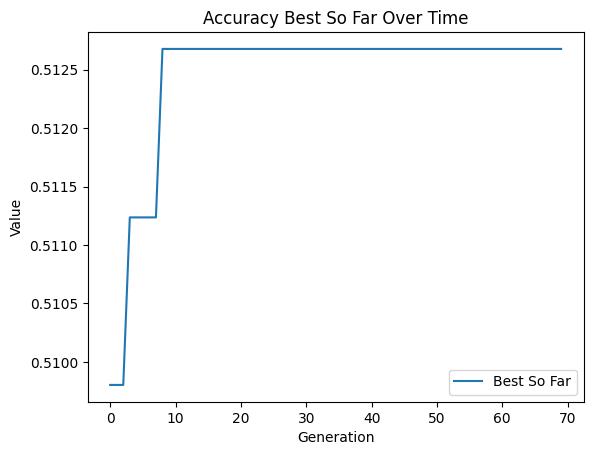

In [11]:
import json
import matplotlib.pyplot as plt

accs = []
evs = []
best_so_far = []  # 用來儲存每個世代中目前最好的值

# # 設定要顯示的最大代數
# max_generations = 50
# path_file = f"{path_out}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}_15pro/"
# path_file = f"{path_out}{stock_id}/20231001_202406302_1/"

print(results_file)
with open(results_file, 'r') as f:
    content = f.readlines()
    current_best = float('-inf')  # 初始化為最小值
    for i, line in enumerate(content):

        result = json.loads(line)
        acc = result['best_fitness']
        accs.append(acc)
        
        # 計算best so far
        if acc > current_best:
            current_best = acc
        best_so_far.append(current_best)

# 繪圖
# plt.plot(accs, label='Accuracy')
plt.plot(best_so_far, label='Best So Far')

plt.title('Accuracy Best So Far Over Time')  # 添加標題
plt.xlabel('Generation')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()  #


## 輸出判斷依據

In [12]:
# individual = [1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0]
individual = best_individual
print(individual)

for i in range(len(individual)):
    if individual[i] == 1:
        print(value_list[i])

# 篩選被選到的元素
selected_elements = {key: value for key, value in skeletons.items() if best_individual[int(key) - 1] == 1}

# 輸出結果
print(selected_elements)


[1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0]
Profit growth: The increase in corporate profits reflects improved profitability, attracting more investors.
Stock price volatility: The extent of stock price fluctuations indicates market reactions and investment risks.
Foreign exchange rate fluctuations: Exchange rate changes directly affect financial performance and market valuations of international companies.
Technological innovation: R&D and the application of new technologies provide competitive advantages and drive growth.
Capital inflows and outflows: Capital flows reflect market confidence and expectations for the company’s prospects.
Predictive financial data: Anticipated financial data releases affect market expectations and stock activity.
New product launch timing: The timing and success of product launches impact market confidence in future growth.
R&D investment changes: Change

IndexError: list index out of range

## 計算使用的費用

In [196]:
# with open(path_out + '/2.json', 'r') as f:
#     content = f.read().strip()
#     data_points = json.loads(content)
# ske = data_points["output_data"]

# # print(ske) 
# print(len(ske))
# # Initialize counters
# total_input_tokens = 0
# total_output_tokens = 0
# total_tokens = 0

# # Loop through each date and each element within skeleton
# for date, date_data in ske.items():
#     for element, element_data in date_data["skeleton"].items():
#         total_input_tokens += element_data["token"]["input_tokens"]
#         total_output_tokens += element_data["token"]["output_tokens"]
#         total_tokens += element_data["token"]["total_tokens"]

# print("Total input tokens:", total_input_tokens)
# print("Total output tokens:", total_output_tokens)
# print("Total tokens:", total_tokens)


# print(f'預估費用 {(total_input_tokens/1000000)*0.15 + (total_output_tokens/1000000)*0.6} USD')